# Olist Initial Purchase Gradient Boosting

## Project objective

This notebook builds the third baseline classifier for predicting whether a customer makes a repeat purchase within 90 days of their initial purchase. It deliberately keeps the Logistic Regression and Random Forest experiment unchanged: the same PostgreSQL source, complete-case population, eight raw predictors, chronological split, target, and evaluation population.

Gradient Boosting builds decision trees sequentially. Each new small tree focuses on mistakes made by the earlier trees, and their contributions are combined into one prediction. Unlike Random Forest, which grows many independent trees and averages them, Gradient Boosting learns a staged correction process. It is a useful third baseline because it tests whether that different tree-ensemble approach can find useful nonlinear patterns without changing the modeling problem.

In [1]:
# Core libraries handle tabular data, plotting, database access, preprocessing, modeling, and evaluation.
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, precision_recall_curve, auc,
    average_precision_score
)

## Load the same modeling table

The table is read from PostgreSQL without changing it. Using the same prepared customer-level source keeps this algorithm comparison fair.

In [2]:
# Connect to the local database that contains the prepared, customer-level modeling table.
engine = create_engine("postgresql+psycopg2://marcusromeo@localhost:5432/olist_project")
# Load the exact source used by the earlier baselines; no data is written back to PostgreSQL.
df = pd.read_sql("SELECT * FROM customer_initial_purchase_model", engine)
print(f"Loaded {len(df):,} customers and {df.shape[1]} columns.")
df.head()

Loaded 86,924 customers and 13 columns.


,customer_unique_id,repeat_purchase_90d,customer_state,first_order_date,first_order_amount,product_amount,freight_amount,products_ordered,unique_products_ordered,number_of_categories,number_of_sellers,payment_installments,freight_to_order_ratio
0,0000366f3b9a7992bf8c76cfdf3221e2,No,SP,2018-05-10 10:56:27,141.90,129.90,12.00,1.0,1.0,1.0,1.0,8.0,0.084567
1,0000b849f77a49e4a4ce2b2a4ca5be3f,No,SP,2018-05-07 11:11:27,27.19,18.90,8.29,1.0,1.0,1.0,1.0,1.0,0.304892
2,0000f46a3911fa3c0805444483337064,No,SC,2017-03-10 21:05:03,86.22,69.00,17.22,1.0,1.0,1.0,1.0,8.0,0.199722
3,0000f6ccb0745a6a4b88665a16c9f078,No,PA,2017-10-12 20:29:41,43.62,25.99,17.63,1.0,1.0,1.0,1.0,4.0,0.404172
4,0004aac84e0df4da2b147fca70cf8255,No,SP,2017-11-14 19:45:42,196.89,180.00,16.89,1.0,1.0,1.0,1.0,6.0,0.085784


## Preserve the complete-case modeling population

These baselines keep the original complete-case approach: first remove rows without an initial-order amount, then remove rows with any remaining missing value. The corrected SQL table can legitimately change the resulting population, so the notebook reports the refreshed counts instead of asserting historical totals. This keeps all three baseline models comparable without introducing imputation in this controlled refresh.

In [3]:
# Preserve the historical complete-case baseline without hard-coding population counts from the pre-correction table.
df_model = df.dropna(subset=["first_order_amount"])
df_final = df_model.dropna().copy()

# Verify the expected table layout and that the modeling population has no remaining missing values.
assert df.shape[1] == 13
assert not df_final.isna().any().any()
print(f"Source population: {len(df):,} customers")
print(f"Final complete-case population: {len(df_final):,} customers")

Source population: 86,924 customers
Final complete-case population: 86,268 customers


## Define the prediction problem

Every predictor describes the initial purchase. The customer ID and order date are excluded, and no later customer behavior is used, so the model does not receive post-purchase information that could leak the answer.

In [4]:
# These eight first-purchase predictors match the final Logistic Regression and Random Forest feature set.
feature_columns = [
    "customer_state",
    "first_order_amount",
    "freight_to_order_ratio",
    "products_ordered",
    "unique_products_ordered",
    "number_of_categories",
    "number_of_sellers",
    "payment_installments",
]
# This is the outcome to predict, not an input feature.
target_column = "repeat_purchase_90d"
assert len(feature_columns) == 8
assert set(feature_columns).issubset(df_final.columns)
assert target_column in df_final.columns
print(f"Raw predictors ({len(feature_columns)}): {feature_columns}")

Raw predictors (8): ['customer_state', 'first_order_amount', 'freight_to_order_ratio', 'products_ordered', 'unique_products_ordered', 'number_of_categories', 'number_of_sellers', 'payment_installments']


## Create the chronological train/test split

Training on earlier initial purchases and testing on later ones better reflects deployment than a random split. The test set stays untouched until final evaluation.

In [5]:
# Split by time so training uses the earliest roughly 80% of customers and testing mimics predictions on later customers.
cutoff_date = df_final["first_order_date"].sort_values().iloc[int(len(df_final) * 0.80)]
train = df_final[df_final["first_order_date"] <= cutoff_date].copy()
test = df_final[df_final["first_order_date"] > cutoff_date].copy()

# X contains only prediction-time-safe initial-purchase features; y is the repeat-purchase outcome.
X_train, X_test = train[feature_columns], test[feature_columns]
y_train = train[target_column].map({"No": 0, "Yes": 1})
y_test = test[target_column].map({"No": 0, "Yes": 1})

assert list(X_train.columns) == feature_columns
assert list(X_test.columns) == feature_columns
assert not X_train.isna().any().any() and not X_test.isna().any().any()

for label, y in [("Train", y_train), ("Test", y_test)]:
    positives = int(y.sum())
    print(f"{label}: {len(y):,} rows | {positives:,} positives | {len(y) - positives:,} negatives | repeat rate: {y.mean():.4%}")
print(f"Chronological cutoff timestamp: {cutoff_date}")

Train: 69,015 rows | 1,458 positives | 67,557 negatives | repeat rate: 2.1126%
Test: 17,253 rows | 226 positives | 17,027 negatives | repeat rate: 1.3099%
Chronological cutoff timestamp: 2018-04-24 09:10:20


## Preprocess categorical and numeric features

Gradient Boosting, like Random Forest, learns splits rather than distance-based relationships, so rescaling numeric predictors is not required. Customer state is one-hot encoded so its categories become model-ready indicator columns.

In [6]:
# Keep state separate because it is categorical; the remaining selected predictors are numeric.
categorical_features = ["customer_state"]
numeric_features = [column for column in feature_columns if column not in categorical_features]

# Apply type-specific preparation consistently while leaving numeric values on their original scale for this tree model.
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        # One indicator per state lets the model use location without imposing a false numeric ordering.
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
# fit_transform learns categories from training data only, preventing information from the test period leaking into preprocessing.
X_train_processed = preprocessor.fit_transform(X_train)
# transform reuses that learned mapping, so test columns exactly match the training representation.
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
assert X_train_processed.shape[1] == X_test_processed.shape[1] == len(feature_names)
print(f"Processed shapes: train {X_train_processed.shape}, test {X_test_processed.shape}")
print(feature_names)

Processed shapes: train (69015, 34), test (17253, 34)
['numeric__first_order_amount' 'numeric__freight_to_order_ratio'
 'numeric__products_ordered' 'numeric__unique_products_ordered'
 'numeric__number_of_categories' 'numeric__number_of_sellers'
 'numeric__payment_installments' 'categorical__customer_state_AC'
 'categorical__customer_state_AL' 'categorical__customer_state_AM'
 'categorical__customer_state_AP' 'categorical__customer_state_BA'
 'categorical__customer_state_CE' 'categorical__customer_state_DF'
 'categorical__customer_state_ES' 'categorical__customer_state_GO'
 'categorical__customer_state_MA' 'categorical__customer_state_MG'
 'categorical__customer_state_MS' 'categorical__customer_state_MT'
 'categorical__customer_state_PA' 'categorical__customer_state_PB'
 'categorical__customer_state_PE' 'categorical__customer_state_PI'
 'categorical__customer_state_PR' 'categorical__customer_state_RJ'
 'categorical__customer_state_RN' 'categorical__customer_state_RO'
 'categorical__cust

## Fit the Gradient Boosting baseline

This uses scikit-learn defaults except for a fixed random seed. No hyperparameter tuning, cross-validation, class weighting, resampling, threshold change, or new features are introduced; that isolates the algorithm choice.

In [7]:
# random_state=42 makes the model's stochastic training process reproducible across runs.
model = GradientBoostingClassifier(random_state=42)
# Learn only from the processed training data and its known outcomes; the test set remains unseen.
model.fit(X_train_processed, y_train)
model

GradientBoostingClassifier(random_state=42)

## Standardized training and test evaluation

All class metrics use the unchanged default 0.50 threshold. ROC-AUC and Average Precision use predicted probabilities and evaluate ranking quality across thresholds. Average Precision is the primary precision-recall summary and should be interpreted against the positive-class prevalence. Training metrics are diagnostic; the later chronological test set remains the generalization comparison.

In [8]:
# Calculate thresholded and probability-ranking metrics identically for training and chronological test data.
def evaluate_model(y_true, predictions, probabilities):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, probabilities)
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "Average Precision": average_precision_score(y_true, probabilities),
        # Retained only as a clearly labelled curve integral; it is not Average Precision.
        "Trapezoidal PR-AUC": auc(recall_curve, precision_curve),
        "Predicted positives at 0.50": int(predictions.sum()),
        "Positive-class prevalence": y_true.mean(),
    }

y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)
y_train_proba = model.predict_proba(X_train_processed)[:, 1]
y_test_proba = model.predict_proba(X_test_processed)[:, 1]

train_metrics = evaluate_model(y_train, y_train_pred, y_train_proba)
test_metrics = evaluate_model(y_test, y_test_pred, y_test_proba)
metrics_table = pd.DataFrame([train_metrics, test_metrics], index=["Training", "Test"])
display(metrics_table)

print("Training confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_train, y_train_pred))
print("\nTest confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, y_test_pred))
print(f"\nROC-AUC train-test gap: {train_metrics['ROC-AUC'] - test_metrics['ROC-AUC']:.4f}")
print(f"Average Precision train-test gap: {train_metrics['Average Precision'] - test_metrics['Average Precision']:.4f}")

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Trapezoidal PR-AUC,Predicted positives at 0.50,Positive-class prevalence
Training,0.979367,1.0,0.02332,0.045576,0.663520,0.114389,0.114527,34,0.021126
Test,0.986205,0.0,0.00000,0.000000,0.533579,0.015011,0.014785,12,0.013099


Training confusion matrix [[TN, FP], [FN, TP]]:
[[67557     0]
 [ 1424    34]]

Test confusion matrix [[TN, FP], [FN, TP]]:
[[17015    12]
 [  226     0]]

ROC-AUC train-test gap: 0.1299
Average Precision train-test gap: 0.0994


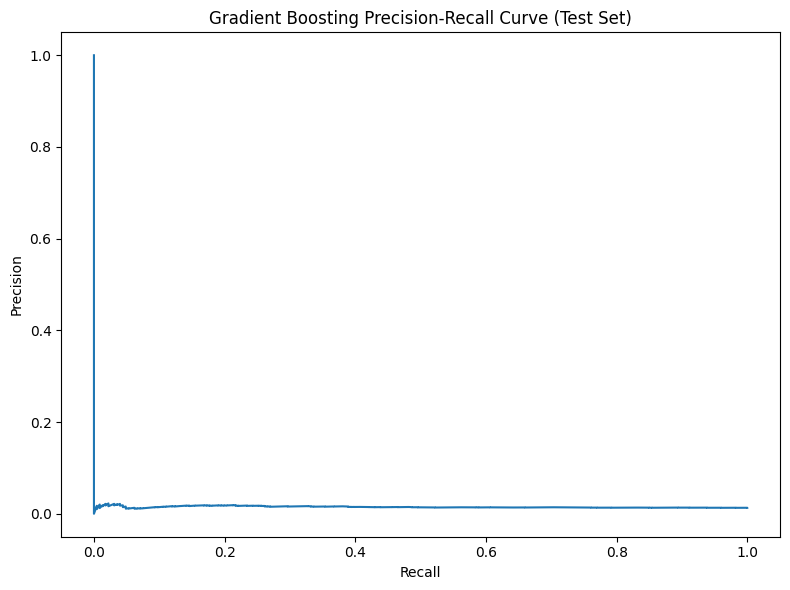

In [9]:
# Plot the requested precision-recall curve for the untouched chronological test set.
test_precision_curve, test_recall_curve, _ = precision_recall_curve(y_test, y_test_proba)
plt.figure(figsize=(8, 6))
plt.plot(test_recall_curve, test_precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Gradient Boosting Precision-Recall Curve (Test Set)")
plt.tight_layout()
plt.show()

## Feature importance

Gradient Boosting provides impurity-based feature importances. They describe model reliance, not causality; can be biased toward certain feature types; do not show the direction of an effect; and deserve extra caution when test performance is weak. State's one-hot columns are summed back into one raw-feature importance for a readable comparison.

,importance
first_order_amount,0.346727
freight_to_order_ratio,0.313187
payment_installments,0.121292
customer_state,0.095723
unique_products_ordered,0.074711
products_ordered,0.038680
number_of_sellers,0.006907
number_of_categories,0.002773


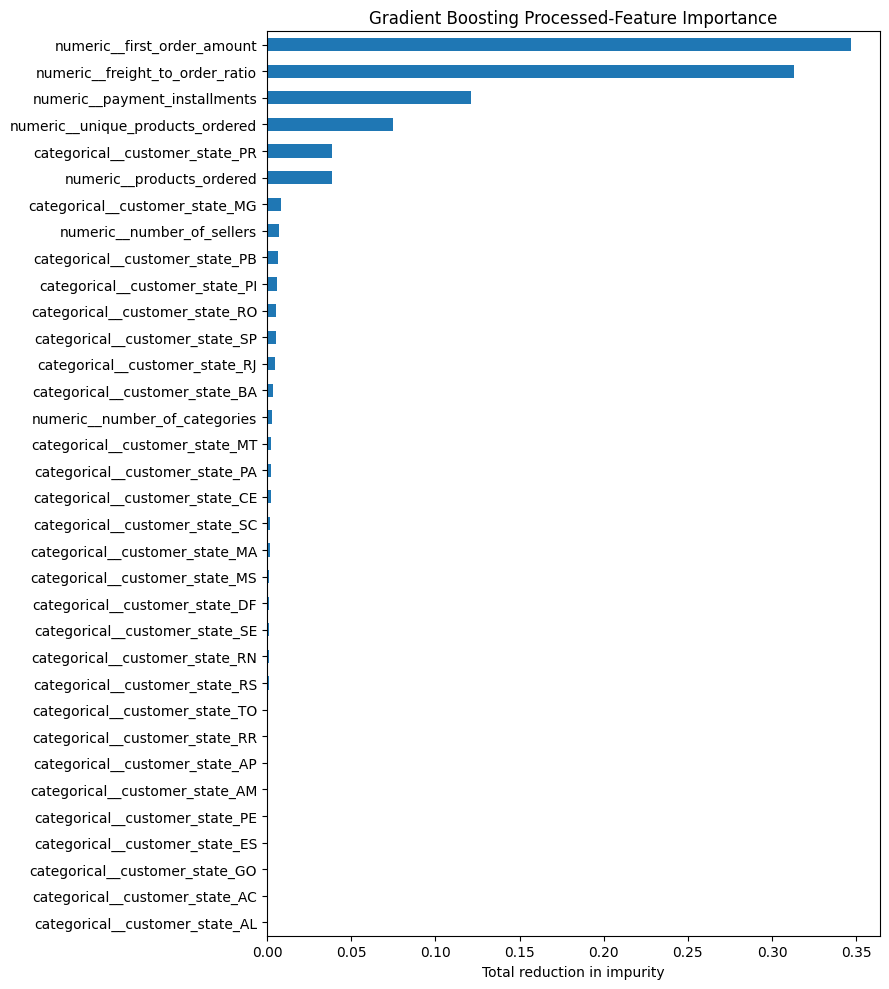

In [10]:
# Match each transformed column to its impurity-based importance from the fitted boosting model.
processed_importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
# Combine all state dummy columns so customer_state can be compared fairly with one-column numeric features.
raw_importance = pd.Series({
    **{column: processed_importance[f"numeric__{column}"] for column in numeric_features},
    "customer_state": processed_importance[
        processed_importance.index.str.startswith("categorical__customer_state_")
    ].sum(),
}).sort_values(ascending=False)
display(raw_importance.rename("importance").to_frame())

processed_importance.sort_values().plot.barh(
    figsize=(9, 10), title="Gradient Boosting Processed-Feature Importance"
)
plt.xlabel("Total reduction in impurity")
plt.tight_layout()
plt.show()

## Cross-model comparison

All three corrected baselines use the same chronological split and original eight-predictor feature set. A repository-level summary will compare their refreshed saved results after every notebook has executed; this notebook avoids carrying forward pre-correction model metrics.

In [11]:
# Cross-model comparison is intentionally deferred until all corrected baseline notebooks have been executed.
# This controlled refresh reports this model's own corrected results without carrying forward historical outputs.
metrics_table

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Trapezoidal PR-AUC,Predicted positives at 0.50,Positive-class prevalence
Training,0.979367,1.0,0.02332,0.045576,0.663520,0.114389,0.114527,34,0.021126
Test,0.986205,0.0,0.00000,0.000000,0.533579,0.015011,0.014785,12,0.013099


In [12]:
# Compare training and test ranking performance: a large gap can indicate overfitting, while weak values on both can indicate limited signal.
roc_gap = train_metrics["ROC-AUC"] - test_metrics["ROC-AUC"]
ap_gap = train_metrics["Average Precision"] - test_metrics["Average Precision"]
print(f"ROC-AUC train-test gap: {roc_gap:.4f}")
print(f"Average Precision train-test gap: {ap_gap:.4f}")
print("Interpret gaps alongside absolute test performance and the chronological change in repeat prevalence; a gap alone is not proof of overfitting.")

ROC-AUC train-test gap: 0.1299
Average Precision train-test gap: 0.0994
Interpret gaps alongside absolute test performance and the chronological change in repeat prevalence; a gap alone is not proof of overfitting.


## Interpretation

Use the executed outputs above as the reproducible record of this corrected baseline. High accuracy can mostly reflect predicting non-repeat purchasers because the target is rare. Interpret Average Precision relative to the positive-class prevalence, and distinguish probability ranking (ROC-AUC and Average Precision) from default-threshold classification metrics.

A large training advantage together with weak chronological test performance suggests overfitting; weak training and test performance suggests limited usable signal in the original first-purchase feature set. Feature importance is descriptive and model-specific, not causal. Threshold selection, class balancing, tuning, time-aware validation, and enriched features are intentionally outside this refresh.